# Sanity Check (YOLO Model)

This notebook contains a quick sanity check to ensure the model is able to train as expected using the implementation. It is using a very small subset of the dataset to run and identify issues quickly.

In [1]:
import sys

import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We start by training the YOLO model with the custom keypoints head on a very small subset of the complete dataset. 

In [4]:
model = detect.CustomHeadedYolo(path="../nets")

# Train the model for some epochs in the dummy dataset.
detect.train_epochs_in(100, None, None, model, testing=True)

epoch 0; train: loss 41.48085021972656; val: loss 32.89390563964844
epoch 1; train: loss 28.505779266357422; val: loss 25.481182098388672
epoch 2; train: loss 22.73922348022461; val: loss 20.521474838256836
epoch 3; train: loss 20.15840721130371; val: loss 20.144649505615234
epoch 4; train: loss 19.57124137878418; val: loss 22.0966739654541
epoch 5; train: loss 19.202129364013672; val: loss 26.094003677368164
epoch 6; train: loss 18.9208984375; val: loss 38.28463363647461
epoch 7; train: loss 18.681331634521484; val: loss 52.6344108581543
epoch 8; train: loss 18.43057632446289; val: loss 63.97454833984375
epoch 9; train: loss 18.191650390625; val: loss 57.18754959106445
epoch 10; train: loss 17.991792678833008; val: loss 36.3324089050293
epoch 11; train: loss 17.89613151550293; val: loss 29.89396858215332
epoch 12; train: loss 17.797962188720703; val: loss 27.011356353759766
epoch 13; train: loss 17.702985763549805; val: loss 25.27317237854004
epoch 14; train: loss 17.61480140686035; v

As can be seen above, the basic implementation of the training loop works, decreasing the loss significantly over the epochs. Obviously this is just on a very small subset of the data so we expect significant overfitting to take place here. Below we look at some examples of applying the learned detector on some example images.

In [7]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/train")
img, ann = data[0]
# Try to run the learned detector on the sample.
detector = detect.CustomPoseDetector(model)
mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
# Try also to use the baseline YOLO model.
detector2 = detect.PoseDetector(path="../nets", compile=False)
mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

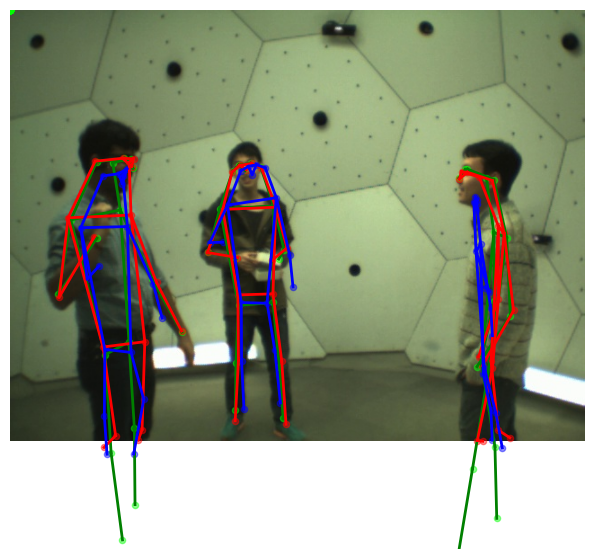

In [8]:
# Visualize the results.
plt.figure(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp in mean.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.axis("off")
plt.show()

As can be seen above, the predictions are not perfect, but they are also not terrible. Note that the red one is the native YOLO prediction, the blue one is the custom heads predictions, and the green skeletons are the ground truth.